# Sustainability Certifications in E-Commerce: A Market Research Study

**Project Overview**

This project investigates how sustainability certifications displayed on Amazon UK beauty product pages relate to real-world market outcomes and consumer perception. The analysis is structured in two phases:

- **Phase 1 - Market Data:** A large-scale scrape of ~15,800 Amazon UK beauty listings to capture price, star ratings, review counts, and the presence of sustainability certification labels (e.g., *Safer Chemicals*, *Organic Content*, *Packaging Efficiency*).
- **Phase 2 - Consumer Survey:** A follow-up survey (N=102) measuring how different certification labels affect consumers' *Green Perceived Value* (GPV).

**Research Questions**

1. How prevalent are sustainability certifications in the beauty category, and which types appear most often?
2. Do certified products command different prices, ratings, or review volumes than non-certified ones?
3. Which certification labels drive the highest consumer green perceived value - and does this vary by gender or environmental identity?

---
## Part 1: Data Collection - Amazon Web Scraper

Product data was collected via a custom asynchronous scraper built with [Scrapfly](https://scrapfly.io/). The scraper pulls product names, prices, star ratings, review counts, and sustainability certification badges from Amazon UK's beauty category (pages 1–400).

Of course, the actual scrape is commented here because the scraping has already been performed.

In [1]:
"""
Amazon UK Beauty Products - Sustainability Scraper
Collects: name, price, rating, review count, sustainability certifications
"""

import os
import asyncio
import json
import re
from typing import List, TypedDict, Optional
from urllib.parse import urljoin, urlparse, parse_qsl, urlencode, urlunparse

from loguru import logger as log
from scrapfly import ScrapeApiResponse, ScrapeConfig, ScrapflyClient
from bs4 import BeautifulSoup

os.environ["SCRAPFLY_KEY"] = "API_KEY"  
SCRAPFLY = ScrapflyClient(key=os.environ["SCRAPFLY_KEY"])
BASE_CONFIG = {"asp": True}

# Amazon UK beauty category - first 400 pages
urls = [
    f"https://www.amazon.co.uk/s?i=beauty&rh=n%3A117332031&s=exact-aware-popularity-rank&fs=true&page={i}"
    for i in range(400)
]


class ProductDetails(TypedDict):
    name: str
    price: Optional[str]
    rating: Optional[float]
    review_count: Optional[int]
    sustainability_certifications: List[str]
    sustainability_count: int
    url: str
    asin: str


class ProductPreview(TypedDict):
    url: str
    title: str
    price: str
    rating: str
    rating_count: str


def _add_or_replace_url_parameters(url: str, **params):
    parsed_url = urlparse(url)
    query_params = dict(parse_qsl(parsed_url.query))
    query_params.update(params)
    updated_url = parsed_url._replace(query=urlencode(query_params))
    return urlunparse(updated_url)


def parse_search(result: ScrapeApiResponse) -> List[ProductPreview]:
    previews = []
    product_boxes = result.selector.css("div.s-result-item[data-component-type=s-search-result]")
    for box in product_boxes:
        url = urljoin(result.context["url"], box.css("div>a::attr(href)").get())
        if not url or "/slredirect/" in url:
            continue
        url = url.split("?")[0]
        rating = box.xpath(
            "//div[@data-cy='reviews-block']//a[contains(@aria-label, 'out of')]/@aria-label"
        ).re_first(r"(\d+\.*\d*) out")
        rating_count = box.xpath(
            "//div[@data-cy='reviews-block']//a[contains(@aria-label, 'ratings')]/@aria-label"
        ).get()
        previews.append({
            "url": url,
            "title": box.css("div>a>h2::attr(aria-label)").get() or "",
            "price": box.css(".a-price[data-a-size=xl] .a-offscreen::text").get() or "",
            "rating": rating,
            "rating_count": rating_count,
        })
    log.info(f"Found {len(previews)} product previews")
    return previews


def extract_sustainability_certifications(html_content: str):
    try:
        soup = BeautifulSoup(html_content, "html.parser")
        cpf_section = soup.find("div", id="climatePledgeFriendlyBadge") or \
                      soup.find("div", class_="climatePledgeFriendly")
        if not cpf_section:
            return [], 0
        count_text_elem = cpf_section.select_one("span.climatePledgeFriendlyProgramName")
        feature_count = 0
        if count_text_elem:
            count_text = count_text_elem.get_text(strip=True)
            count_match = re.search(r"(\d+)\s+sustainability", count_text)
            feature_count = int(count_match.group(1)) if count_match else 0
        pattern = r'<span class="cpf-dpx-expander-title a-text-bold">\s*(.*?)\s*</span>'
        certifications = [c.strip() for c in re.findall(pattern, html_content) if c.strip()]
        return certifications, feature_count
    except Exception as e:
        log.debug(f"Error extracting certs: {e}")
        return [], 0


def parse_product_details(result: ScrapeApiResponse) -> ProductDetails:
    sel = result.selector
    name = sel.css("#productTitle::text").get("").strip()
    asin = sel.css("input[name=ASIN]::attr(value)").get("").strip()
    price = (
        sel.css(".a-price .a-offscreen::text").get() or
        sel.css("#priceblock_dealprice::text").get() or
        sel.css("#priceblock_ourprice::text").get() or
        sel.css(".a-price-whole::text").get() or ""
    ).strip()
    rating_text = sel.css("i[data-hook=average-star-rating] ::text").get("").strip()
    rating = None
    if rating_text:
        m = re.search(r"(\d+\.?\d*)", rating_text)
        if m:
            rating = float(m.group(1))
    review_count_text = sel.css("span[data-hook=total-review-count] ::text").get("").strip()
    review_count = None
    if review_count_text:
        m = re.search(r"([\d,]+)", review_count_text.replace(",", ""))
        if m:
            review_count = int(m.group(1))
    certifications, cert_count = extract_sustainability_certifications(result.content)
    return {
        "name": name, "price": price if price else None, "rating": rating,
        "review_count": review_count, "sustainability_certifications": certifications,
        "sustainability_count": cert_count, "url": result.context["url"], "asin": asin,
    }


async def scrape_product_details(url: str) -> ProductDetails:
    url = url.split("/ref=")[0]
    try:
        result = await SCRAPFLY.async_scrape(ScrapeConfig(
            url, **BASE_CONFIG, render_js=True, wait_for_selector="#productTitle"
        ))
        return parse_product_details(result)
    except Exception as e:
        log.error(f"Error scraping {url}: {e}")
        return {
            "name": "Error loading product", "price": None, "rating": None,
            "review_count": None, "sustainability_certifications": [],
            "sustainability_count": 0, "url": url, "asin": "",
        }


async def scrape_all_products(urls):
    log.info("Step 1: Scraping search pages...")
    search_configs = [ScrapeConfig(url, **BASE_CONFIG) for url in urls]
    search_results = []
    async for result in SCRAPFLY.concurrent_scrape(search_configs):
        search_results.extend(parse_search(result))
    log.info(f"Found {len(search_results)} products")

    log.info("Step 2: Scraping product pages...")
    semaphore = asyncio.Semaphore(5)

    async def scrape_with_semaphore(url):
        async with semaphore:
            return await scrape_product_details(url)

    tasks = [scrape_with_semaphore(p["url"]) for p in search_results]
    results = await asyncio.gather(*tasks, return_exceptions=True)
    valid = [p for p in results if isinstance(p, dict)]
    log.info(f"Successfully scraped {len(valid)} products")
    return valid


def save_results(products, filename="amazon_products.json"):
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(products, f, indent=2, ensure_ascii=False)
    log.info(f"Saved {len(products)} products to {filename}")


# async def main():
#     products = await scrape_all_products(urls)
#     save_results(products)
#     total_certified = sum(1 for p in products if p['sustainability_certifications'])
#     print(f"Scraped {len(products)} products | {total_certified} certified")
# asyncio.run(main())

---
## Part 2: Product Market Data Analysis

### 2.1 - Data Loading & Cleaning

The scraped JSON is converted to CSV with pandas, then cleaned: error rows are dropped, the `£` symbol is stripped from prices, and a binary `sustainability` indicator is created (1 = any certification present).

In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from stargazer.stargazer import Stargazer

In [3]:
# Convert JSON → CSV
# df_raw = pd.read_json("amazon_products.json")
# df_raw.to_csv("Data file.csv", encoding="utf-8", index=False)

# Load from CSV
df = pd.read_csv("Data file.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (19720, 8)


,name,price,rating,review_count,sustainability_certifications,sustainability_count,url,asin
0,Error loading product,NaN,NaN,NaN,[],0,https://www.amazon.co.uk/Crochet-Pre-Looped-Go...,NaN
1,Error loading product,NaN,NaN,NaN,[],0,https://www.amazon.co.uk/Heathcote-Ivory-Sweet...,NaN
2,Yueshop Glitter Gel Nail Polish Set- 10 PCS Ge...,£7.16,4.3,2286.0,[],0,https://www.amazon.co.uk/Yueshop-Polishes-Glit...,B08SCL8YQS
3,PROVOKE Touch Of Silver Hydrating Purple Tonin...,£18.95,4.4,1491.0,[],0,https://www.amazon.co.uk/PRO-Hydrating-Conditi...,B08LVBWTLX
4,Manicure Set Professional Nail Clippers Kit -1...,£10.23,4.5,1816.0,[],0,https://www.amazon.co.uk/Manicure-Professional...,B08H1V8D6X


In [4]:
# Remove failed scrapes, clean price, create sustainability flag
df = df[df.name != "Error loading product"].copy()
df = df[df.name.notnull()]
df["price"] = df["price"].str.replace("\u00a3", "", regex=False).astype(float)
df["sustainability"] = np.where(df.sustainability_count == 0, 0, 1)

print(f"Clean dataset shape: {df.shape}")
df.head()

Clean dataset shape: (15814, 9)


,name,price,rating,review_count,sustainability_certifications,sustainability_count,url,asin,sustainability
2,Yueshop Glitter Gel Nail Polish Set- 10 PCS Ge...,7.16,4.3,2286.0,[],0,https://www.amazon.co.uk/Yueshop-Polishes-Glit...,B08SCL8YQS,0
3,PROVOKE Touch Of Silver Hydrating Purple Tonin...,18.95,4.4,1491.0,[],0,https://www.amazon.co.uk/PRO-Hydrating-Conditi...,B08LVBWTLX,0
4,Manicure Set Professional Nail Clippers Kit -1...,10.23,4.5,1816.0,[],0,https://www.amazon.co.uk/Manicure-Professional...,B08H1V8D6X,0
7,Jumiso Vitamin serum & Hyaluronic Acid for fac...,13.69,4.3,1605.0,[],0,https://www.amazon.co.uk/Vitamin-Brightening-B...,B07QSF1LK3,0
8,"Cremo Men's Eau de Toilette, Spice and Black V...",33.66,NaN,NaN,[],0,https://www.amazon.co.uk/CREMO-Toilette-100ml-...,B079C2P64T,0


### 2.2 - Certification Prevalence

How common are sustainability certifications across the ~15,800 products?

In [5]:
total     = df.sustainability.count()
certified = int(df.sustainability.sum())
pct       = df.sustainability.mean() * 100

print(f"Total products:            {total:,}")
print(f"With at least 1 cert:      {certified:,}")
print(f"Percentage with cert:      {pct:.1f}%")

Total products:            15,814
With at least 1 cert:      806
Percentage with cert:      5.1%


In [6]:
# Among certified products: how many certs do they typically have?
certified_only = df.loc[df.sustainability == 1, "sustainability_count"]
print(f"Mean certs per certified product:  {certified_only.mean():.2f}")
print(f"Median:                            {certified_only.median():.1f}")
print(f"Std dev:                           {certified_only.std():.2f}")

unique_vals, counts = np.unique(certified_only, return_counts=True)
print("\nDistribution:")
for v, c in zip(unique_vals, counts):
    print(f"  {int(v)} cert(s): {c} products")

Mean certs per certified product:  1.42
Median:                            1.0
Std dev:                           0.85

Distribution:
  1 cert(s): 639 products
  2 cert(s): 12 products
  3 cert(s): 138 products
  4 cert(s): 15 products
  5 cert(s): 2 products


In [7]:
# Parse stringified lists and count occurrences of each cert type
df["sustainability_certifications"] = df["sustainability_certifications"].apply(
    lambda x: ast.literal_eval(x) if x != "[]" else []
)
cert_counts = df["sustainability_certifications"].explode().value_counts()
print("Certification type frequencies:")
print(cert_counts.to_string())

Certification type frequencies:
sustainability_certifications
Packaging efficiency       388
Safer chemicals            225
Worker well-being          102
Carbon impact               96
Organic content             80
Manufacturing practices     67
Farming practices           34
Recycled materials          33
Biodiversity                30
Animal welfare              27
Energy efficiency           16
Forestry practices          12


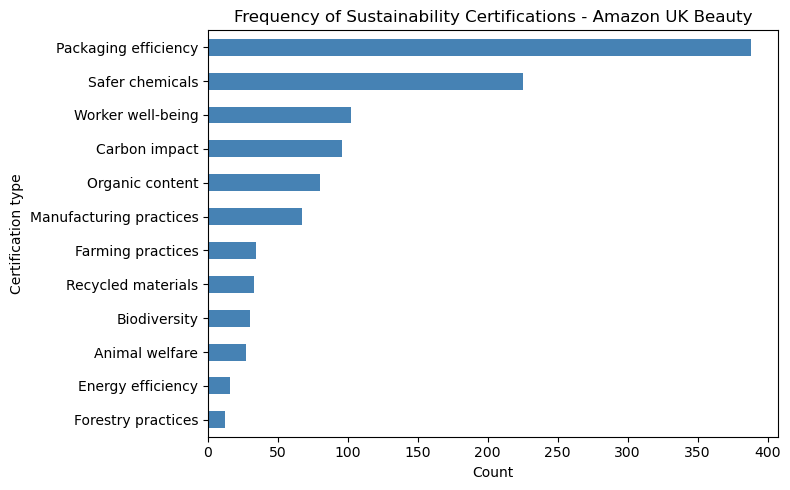

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
cert_counts.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Count")
ax.set_ylabel("Certification type")
ax.set_title("Frequency of Sustainability Certifications - Amazon UK Beauty")
plt.tight_layout()
plt.show()

### 2.3 - Market Outcome Differences: Certified vs. Non-Certified

We use Welch's *t*-tests (preceded by Levene's test for variance equality) to compare the two groups on **price**, **star rating**, and **review count**. Cohen's *d* is reported as an effect-size estimate.

In [9]:
def compare_groups(df, dv, group="sustainability"):
    print(f"\n{'='*55}")
    print(f"  {dv.upper()}")
    print(f"{'='*55}")

    g0 = df.loc[df[group] == 0, dv].dropna()
    g1 = df.loc[df[group] == 1, dv].dropna()

    stat, levene_p = stats.levene(g0, g1)
    print(f"Levene's test: F = {stat:.3f}, p = {levene_p:.4f}")

    equal_var  = levene_p > 0.05
    t_res      = stats.ttest_ind(g0, g1, equal_var=equal_var)
    test_label = "Student's t" if equal_var else "Welch's t"
    print(f"{test_label}: t = {t_res.statistic:.3f}, p = {t_res.pvalue:.6f}")

    print("\nDescriptives (0 = no cert, 1 = has cert):")
    print(df.groupby(group)[dv].describe().to_string())
    print("\nMedians:")
    print(df.groupby(group)[dv].median().to_string())

    n0, n1 = len(g0), len(g1)
    pooled  = np.sqrt(((n0 - 1) * g0.std()**2 + (n1 - 1) * g1.std()**2) / (n0 + n1 - 2))
    d       = (g0.mean() - g1.mean()) / pooled
    print(f"Cohen's d = {d:.3f}")


for dv in ["price", "rating", "review_count"]:
    compare_groups(df, dv)


  PRICE
Levene's test: F = 7.497, p = 0.0062
Welch's t: t = -3.452, p = 0.000583

Descriptives (0 = no cert, 1 = has cert):
                  count       mean        std   min   25%    50%    75%     max
sustainability                                                                 
0               14827.0  13.442121  16.698642  0.49  6.14   9.21  15.99  469.99
1                 799.0  16.208773  22.318060  1.49  7.45  11.20  17.99  327.88

Medians:
sustainability
0     9.21
1    11.20
Cohen's d = -0.162

  RATING
Levene's test: F = 23.158, p = 0.0000
Welch's t: t = -5.066, p = 0.000000

Descriptives (0 = no cert, 1 = has cert):
                  count      mean       std  min  25%  50%  75%  max
sustainability                                                      
0               13606.0  4.363009  0.321661  1.0  4.2  4.4  4.6  5.0
1                 740.0  4.409189  0.236339  3.2  4.3  4.4  4.6  4.9

Medians:
sustainability
0    4.4
1    4.4
Cohen's d = -0.145

  REVIEW_COUNT
Levene's

### 2.4 - OLS Regression with 80 / 20 Train–Test Split

Within the subset of **certified products only**, we one-hot encode each certification type and fit separate OLS regression models predicting price, rating, and review count from those dummy variables.

An **80/20 train–test split** (stratified, random state = 42) is used to evaluate out-of-sample predictive performance alongside in-sample fit. Reported metrics: in-sample R², out-of-sample R², and test-set RMSE.

In [10]:
# One-hot encode certification types
dummies    = df["sustainability_certifications"].explode().str.get_dummies().groupby(level=0).max()
df_binary  = pd.concat([df, dummies], axis=1)
df_cert    = df_binary[df_binary["sustainability"] == 1].copy()

cert_cols  = list(dummies.columns)
print(f"Certification columns ({len(cert_cols)}): {cert_cols}")
print(f"Certified product rows: {len(df_cert)}")

Certification columns (12): ['Animal welfare', 'Biodiversity', 'Carbon impact', 'Energy efficiency', 'Farming practices', 'Forestry practices', 'Manufacturing practices', 'Organic content', 'Packaging efficiency', 'Recycled materials', 'Safer chemicals', 'Worker well-being']
Certified product rows: 806


In [11]:
# 80 / 20 split - random_state for reproducibility
df_train, df_test = train_test_split(df_cert, test_size=0.20, random_state=42)

print(f"Train set: {len(df_train)} rows  ({len(df_train)/len(df_cert)*100:.0f}%)")
print(f"Test set:  {len(df_test)} rows  ({len(df_test)/len(df_cert)*100:.0f}%)")

Train set: 644 rows  (80%)
Test set:  162 rows  (20%)


In [12]:
def run_ols(train_df, test_df, dv, predictors):
    """
    Fit OLS on train_df, evaluate predictions on test_df.
    Returns fitted model and evaluation metrics.
    """
    # Training
    y_train  = train_df[dv].dropna()
    X_train  = sm.add_constant(train_df.loc[y_train.index, predictors])
    model    = sm.OLS(y_train, X_train).fit()

    # Test
    y_test   = test_df[dv].dropna()
    X_test   = sm.add_constant(test_df.loc[y_test.index, predictors])
    X_test   = X_test.reindex(columns=X_train.columns, fill_value=0)
    y_pred   = model.predict(X_test)

    rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_test  = r2_score(y_test, y_pred)

    return model, {
        "dv":       dv,
        "n_train":  len(y_train),
        "n_test":   len(y_test),
        "R2_train": model.rsquared,
        "R2_test":  r2_test,
        "RMSE_test": rmse,
    }


fitted_models = []
all_metrics   = []

for dv in ["price", "rating", "review_count"]:
    model, metrics = run_ols(df_train, df_test, dv, cert_cols)
    fitted_models.append(model)
    all_metrics.append(metrics)

# Validation summary table
header = f"{'Outcome':<15} {'R² (train)':>12} {'R² (test)':>11} {'RMSE (test)':>13} {'N train':>9} {'N test':>8}"
print(header)
print("-" * len(header))
for m in all_metrics:
    print(f"{m['dv']:<15} {m['R2_train']:>12.3f} {m['R2_test']:>11.3f} {m['RMSE_test']:>13.2f} {m['n_train']:>9} {m['n_test']:>8}")

Outcome           R² (train)   R² (test)   RMSE (test)   N train   N test
-------------------------------------------------------------------------
price                  0.392       0.138         34.09       638      161
rating                 0.049      -0.014          0.21       594      146
review_count           0.056       0.023       7434.39       594      146


In [13]:
# Formal regression table (train-set models)
from IPython.display import HTML

stargazer = Stargazer(fitted_models)
stargazer.title(
    "OLS Regression: Certification Type → Market Outcomes "
    "(Train Set, Certified Products Only)"
)
stargazer.custom_columns(["Price (\u00a3)", "Rating (★)", "Review Count"], [1, 1, 1])
HTML(stargazer.render_html())

### 2.5 - Random Forest Regression with 80/20 Train–Test Split

Using the **same** 80/20 train–test split and one-hot encoded certification-type predictors, we fit a **Random Forest Regressor** for each of the three outcomes: price, rating, and review count.  Random forests are a natural complement to the OLS models above because they capture non-linearities and interactions between certification types without requiring distributional assumptions.

Reported metrics mirror the OLS table: in-sample R², out-of-sample R², and test-set RMSE. **Feature importances** (mean decrease in impurity, averaged across trees) then show which certification types drive each prediction—analogous to the coefficient table above.

In [14]:
from sklearn.ensemble import RandomForestRegressor

def run_rf(train_df, test_df, dv, predictors, n_estimators=300, random_state=42):
    """
    Fit a Random Forest on train_df, evaluate predictions on test_df.
    Returns fitted model and evaluation metrics.
    """
    y_train = train_df[dv].dropna()
    X_train = train_df.loc[y_train.index, predictors]

    y_test  = test_df[dv].dropna()
    X_test  = test_df.loc[y_test.index, predictors]
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

    rf = RandomForestRegressor(
        n_estimators=n_estimators, random_state=random_state, n_jobs=-1
    )
    rf.fit(X_train, y_train)

    y_pred_train = rf.predict(X_train)
    y_pred_test  = rf.predict(X_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test  = r2_score(y_test,  y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))

    return rf, {
        "dv":        dv,
        "n_train":   len(y_train),
        "n_test":    len(y_test),
        "R2_train":  r2_train,
        "R2_test":   r2_test,
        "RMSE_test": rmse,
    }


rf_models  = []
rf_metrics = []

for dv in ["price", "rating", "review_count"]:
    rf, metrics = run_rf(df_train, df_test, dv, cert_cols)
    rf_models.append(rf)
    rf_metrics.append(metrics)

# Validation summary table
header = f"{'Outcome':<15} {'R\u00b2 (train)':>12} {'R\u00b2 (test)':>11} {'RMSE (test)':>13} {'N train':>9} {'N test':>8}"
print(header)
print("-" * len(header))
for m in rf_metrics:
    print(
        f"{m['dv']:<15} {m['R2_train']:>12.3f} {m['R2_test']:>11.3f} "
        f"{m['RMSE_test']:>13.2f} {m['n_train']:>9} {m['n_test']:>8}"
    )

Outcome           R² (train)   R² (test)   RMSE (test)   N train   N test
-------------------------------------------------------------------------
price                  0.407       0.154         33.77       638      161
rating                 0.054      -0.009          0.21       594      146
review_count           0.122       0.041       7364.08       594      146


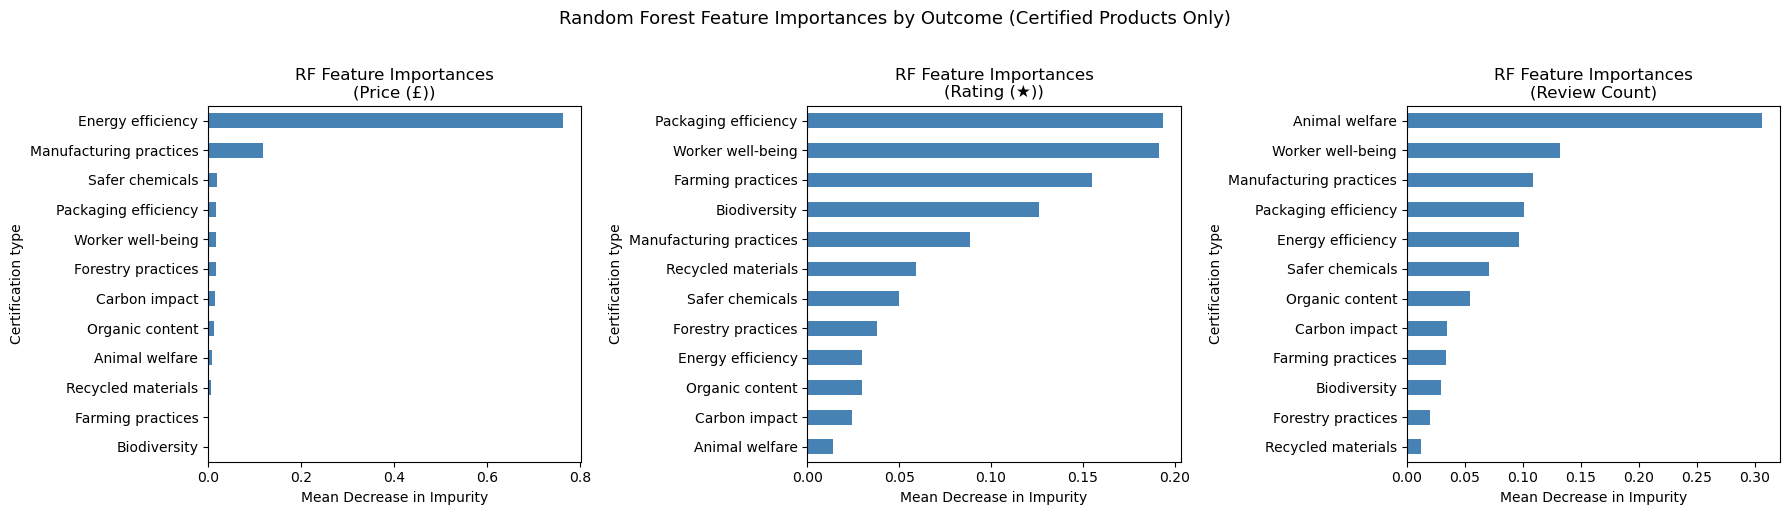

In [15]:
# Feature importances (mean decrease in impurity) for each RF model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
outcome_labels = ["Price (\u00a3)", "Rating (\u2605)", "Review Count"]

for ax, rf, label in zip(axes, rf_models, outcome_labels):
    importances = (
        pd.Series(rf.feature_importances_, index=cert_cols)
        .sort_values(ascending=True)
    )
    importances.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"RF Feature Importances\n({label})")
    ax.set_xlabel("Mean Decrease in Impurity")
    ax.set_ylabel("Certification type")

plt.suptitle(
    "Random Forest Feature Importances by Outcome (Certified Products Only)",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

---
## Part 3: Consumer Survey - Green Perceived Value

### 3.1 - Data Loading & Preprocessing

A survey (N = 102) measured how six Amazon Climate Pledge Friendly certification labels affect consumers' **Green Perceived Value** (GPV) - a composite of five Likert-scale items per label (1–5 scale). An embedded attention-check item was used to filter low-quality responses before analysis.

In [16]:
import scipy.stats as sc
import statsmodels.formula.api as smf

In [17]:
# Load raw survey data
Data = pd.read_csv("Green beauty claims perception.csv")
print(f"Raw rows before attention-check filter: {len(Data)}")
Data.head()

Raw rows before attention-check filter: 103


,Timestamp,"After seeing this claim, I would consider this product’s environmental features to provide very good value for me.","After seeing this claim, I would feel this product’s environmental performance meets my expectations.","After seeing this claim, I would be more likely to purchase this product because it demonstrates greater environmental concern than other products.","After seeing this claim, I would purchase this product because it is environmentally friendly.","After seeing this claim, I would purchase this product because it offers greater environmental benefits than other products.","After seeing this claim, I would consider this product’s environmental features to provide very good value for me. .1","After seeing this claim, I would feel this product’s environmental performance meets my expectations. .1","After seeing this claim, I would be more likely to purchase this product because it demonstrates greater environmental concern than other products. .1","After seeing this claim, I would purchase this product because it is environmentally friendly. .1",...,"After seeing this claim, I would purchase this product because it is environmentally friendly. .4","After seeing this claim, I would purchase this product because it offers greater environmental benefits than other products. .4","After seeing this claim, I would consider this product’s environmental features to provide very good value for me. .5","After seeing this claim, I would feel this product’s environmental performance meets my expectations. .5","After seeing this claim, I would be more likely to purchase this product because it demonstrates greater environmental concern than other products. .5","After seeing this claim, I would purchase this product because it is environmentally friendly. .5","After seeing this claim, I would purchase this product because it offers greater environmental benefits than other products. .5",What is your age?,What is your gender?,I perceive myself as someone who helps to protect the environment.
0,2025/09/24 5:51:52 pm EEST,3,4,4,4,4,3,3,3,3,...,3,3,4,4,3,4,3,58,Female,Agree
1,2025/09/24 5:52:39 pm EEST,4,5,1,5,5,5,5,5,5,...,5,5,5,5,5,5,5,32,Female,Strongly Agree
2,2025/09/24 5:53:59 pm EEST,5,5,5,5,5,1,1,1,1,...,5,5,5,5,5,5,5,29,Male,Strongly Agree
3,2025/09/24 5:54:16 pm EEST,4,4,4,4,4,5,5,5,5,...,4,4,4,4,4,4,4,40,Male,Agree
4,2025/09/24 5:54:17 pm EEST,1,1,1,1,1,4,4,3,3,...,4,4,2,2,2,2,2,39,Male,Strongly disagree


In [18]:
# Retain only participants who passed the attention check (correct answer = 4)
Data = Data[Data["This question is an attention check. Please answer with a 4."] == 4]
print(f"Rows after attention-check filter: {len(Data)}")

# Compute mean GPV score per certificate label (5 items each)
cols_1 = [c for c in Data.columns if c.endswith("1")]
cols_2 = [c for c in Data.columns if c.endswith("2")]
cols_3 = [c for c in Data.columns if c.endswith("3")]
cols_4 = [c for c in Data.columns if c.endswith("4")]
cols_5 = [c for c in Data.columns if c.endswith("5")]

Data["Packaging efficiency"]    = Data.iloc[:, 1:5].mean(axis=1)
Data["Safer chemicals"]         = Data[cols_1].mean(axis=1)
Data["Worker well-being"]       = Data[cols_2].mean(axis=1)
Data["Carbon impact"]           = Data[cols_3].mean(axis=1)
Data["Organic content"]         = Data[cols_4].mean(axis=1)
Data["Manufacturing practices"] = Data[cols_5].mean(axis=1)

print("GPV composite scores computed for 6 certificate labels.")

Rows after attention-check filter: 102
GPV composite scores computed for 6 certificate labels.


### 3.2 - Sample Descriptive Statistics

In [19]:
# Select outcome + demographic columns
Data_clean = Data.iloc[:, -9:].copy()

# Map environmental identity (Likert text → numeric)
env_map = {
    "Strongly Agree": 5, "Agree": 4, "Neutral": 3, "Disagree": 2, "Strongly disagree": 1
}
Data_clean["Environmentalism"] = Data_clean[
    "I perceive myself as someone who helps to protect the environment."
].map(env_map)

print("=== Numeric summary ===")
print(Data_clean.describe().to_string())
print("\n=== Gender breakdown ===")
print(Data_clean["What is your gender?"].value_counts().to_string())
print("\n=== Environmental identity ===")
print(
    Data_clean["I perceive myself as someone who helps to protect the environment."]
    .value_counts()
    .to_string()
)

=== Numeric summary ===
       What is your age?  Packaging efficiency  Safer chemicals  Worker well-being  Carbon impact  Organic content  Manufacturing practices  Environmentalism
count         102.000000            102.000000       102.000000         102.000000     102.000000       102.000000               102.000000        102.000000
mean           46.421569              3.394608         3.545098           3.403922       3.625490         3.529412                 3.441176          3.862745
std            13.833834              0.893068         0.972150           1.044355       1.026644         0.954675                 1.008612          0.821002
min            20.000000              1.000000         1.000000           1.000000       1.000000         1.000000                 1.000000          1.000000
25%            35.250000              2.750000         3.000000           3.000000       3.050000         3.000000                 2.850000          4.000000
50%            48.500000    

### 3.3 - GPV by Certificate Label

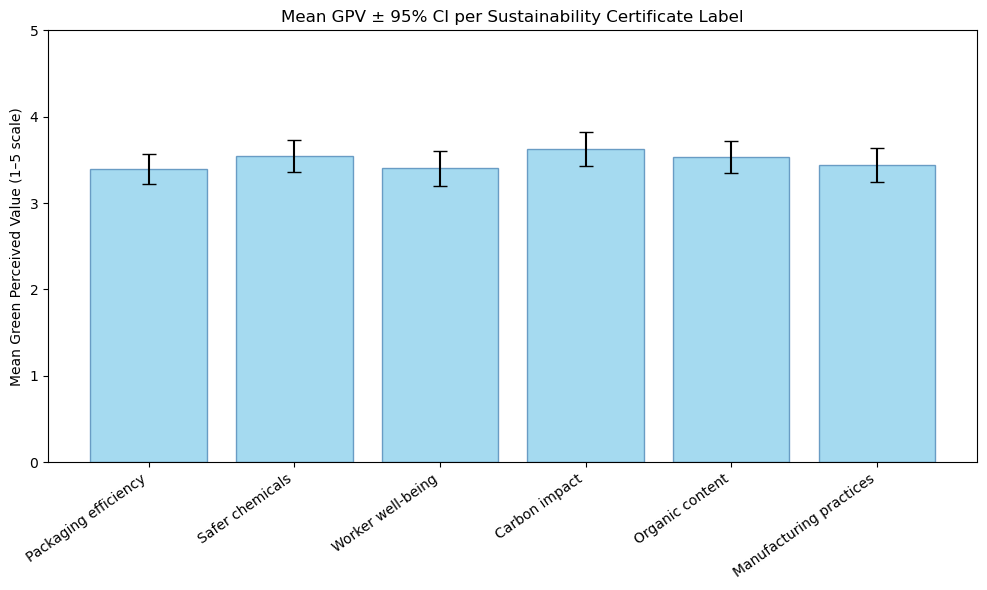

In [20]:
certificate_vars = [
    "Packaging efficiency", "Safer chemicals", "Worker well-being",
    "Carbon impact", "Organic content", "Manufacturing practices",
]

means = Data_clean[certificate_vars].mean()
sds   = Data_clean[certificate_vars].std()
ns    = Data_clean[certificate_vars].count()
cis   = 1.96 * (sds / np.sqrt(ns))

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    means.index, means.values,
    yerr=cis, capsize=5, alpha=0.75,
    color="skyblue", edgecolor="steelblue"
)
ax.set_ylabel("Mean Green Perceived Value (1\u20135 scale)")
ax.set_title("Mean GPV \u00b1 95% CI per Sustainability Certificate Label")
ax.set_ylim(0, 5)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### 3.4 - Correlation Matrix

In [21]:
cols   = Data_clean.columns[np.r_[0, 3:10]]
sub_df = Data_clean.iloc[:, np.r_[0, 3:10]]

corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
p_matrix    = pd.DataFrame(index=cols, columns=cols, dtype=float)

for col1 in cols:
    for col2 in cols:
        if col1 == col2:
            corr_matrix.loc[col1, col2] = 1.0
            p_matrix.loc[col1, col2]    = 0.0
        else:
            r, p = sc.pearsonr(sub_df[col1], sub_df[col2])
            corr_matrix.loc[col1, col2] = round(r, 3)
            p_matrix.loc[col1, col2]    = round(p, 4)

print("Pearson correlation matrix (r):")
print(corr_matrix.to_string())
print("\np-values:")
print(p_matrix.to_string())

Pearson correlation matrix (r):
                         What is your age?  Packaging efficiency  Safer chemicals  Worker well-being  Carbon impact  Organic content  Manufacturing practices  Environmentalism
What is your age?                    1.000                -0.213           -0.243             -0.104         -0.180           -0.162                   -0.125             0.028
Packaging efficiency                -0.213                 1.000            0.330              0.276          0.511            0.384                    0.555             0.476
Safer chemicals                     -0.243                 0.330            1.000              0.377          0.384            0.486                    0.437             0.189
Worker well-being                   -0.104                 0.276            0.377              1.000          0.320            0.444                    0.491             0.336
Carbon impact                       -0.180                 0.511            0.384       

### 3.5 - Linear Mixed Model: Certificate × Gender with Covariates

A linear mixed-effects model (random intercept per subject) predicts GPV from **certificate type**, **gender**, their **interaction**, and the covariates **age** and **environmental self-identity**. Data are in long format (6 observations per participant, one per certificate label).

Omnibus Wald tests assess the significance of each fixed effect.

In [22]:
gender_col = "What is your gender?"
age_col    = "What is your age?"
env_col    = "Environmentalism"

# Reshape to long format
DATA = Data_clean.copy().reset_index().rename(columns={"index": "subject_id"})
long = DATA.melt(
    id_vars=["subject_id", gender_col, age_col, env_col],
    value_vars=certificate_vars,
    var_name="certificate",
    value_name="perceived_value",
)
long = long.dropna(subset=["perceived_value", gender_col, age_col, env_col])
long["certificate"] = long["certificate"].astype("category")
long["gender"]      = long[gender_col].astype("category")
long["age"]         = pd.to_numeric(long[age_col], errors="coerce")
long["env"]         = pd.to_numeric(long[env_col], errors="coerce")
long = long.dropna(subset=["age", "env", "gender"])

print(f"Long-format rows: {len(long)} (expected ~{len(Data_clean) * len(certificate_vars)})")

# Fit mixed model
formula = "perceived_value ~ C(certificate) * C(gender) + age + env"
md = smf.mixedlm(formula, data=long, groups=long["subject_id"])
try:
    mdf = md.fit(reml=False)
except Exception:
    mdf = md.fit(reml=False, method="nm", maxiter=2000)

print(mdf.summary())

Long-format rows: 612 (expected ~612)
                                Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              perceived_value
No. Observations:                612                  Method:                          ML             
No. Groups:                      102                  Scale:                           0.5380         
Min. group size:                 6                    Log-Likelihood:                  -742.9590      
Max. group size:                 6                    Converged:                       Yes            
Mean group size:                 6.0                                                                  
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------

In [23]:
# Omnibus Wald tests for main effects and interaction
param_names = list(mdf.params.index)

def omnibus_wald(indices):
    if not indices:
        return None
    k   = len(param_names)
    q   = len(indices)
    R   = np.zeros((q, k))
    for i, idx in enumerate(indices):
        R[i, idx] = 1.0
    wres = mdf.wald_test(R)
    stat = float(np.array(wres.statistic).flat[0])
    pval = float(np.array(wres.pvalue).flat[0])
    return {"chi2": stat, "df": q, "p": pval}

cert_main_idx  = [i for i, n in enumerate(param_names) if n.startswith("C(certificate)") and ":" not in n]
gender_main_idx = [i for i, n in enumerate(param_names) if n.startswith("C(gender)") and ":" not in n]
inter_idx       = [i for i, n in enumerate(param_names) if "C(certificate)" in n and "C(gender)" in n]
age_idx         = [i for i, n in enumerate(param_names) if n == "age"]
env_idx         = [i for i, n in enumerate(param_names) if n == "env"]

test_results = {
    "Certificate (main effect)":            omnibus_wald(cert_main_idx),
    "Gender (main effect)":                 omnibus_wald(gender_main_idx),
    "Certificate × Gender (interaction)":  omnibus_wald(inter_idx),
    "Age (covariate)":                      omnibus_wald(age_idx),
    "Environmental identity (covariate)":   omnibus_wald(env_idx),
}

rows = [
    {"Effect": name, "\u03c7\u00b2": r["chi2"], "df": r["df"], "p": r["p"]}
    for name, r in test_results.items() if r
]
omni_df = pd.DataFrame(rows).set_index("Effect")
print("\nOmnibus Wald Test Results:")
print(omni_df.to_string(float_format="%.4f"))


Omnibus Wald Test Results:
                                        χ²  df      p
Effect                                               
Certificate (main effect)          12.7985   5 0.0253
Gender (main effect)                6.3860   1 0.0115
Certificate × Gender (interaction)  7.4628   5 0.1884
Age (covariate)                    10.4715   1 0.0012
Environmental identity (covariate) 44.1816   1 0.0000


C:\Users\Sloba\miniconda3\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [24]:
# Descriptive means by certificate × gender
emm = (
    long.groupby(["certificate", "gender"], observed=True)["perceived_value"]
    .agg(["mean", "count", "std"])
    .assign(se=lambda x: x["std"] / np.sqrt(x["count"]))
)
print("Mean GPV by certificate type and gender:")
print(emm.to_string(float_format="%.3f"))

Mean GPV by certificate type and gender:
                                mean  count   std    se
certificate             gender                         
Carbon impact           Female 3.866     58 0.842 0.111
                        Male   3.309     44 1.164 0.176
Manufacturing practices Female 3.607     58 0.885 0.116
                        Male   3.223     44 1.125 0.170
Organic content         Female 3.607     58 0.875 0.115
                        Male   3.427     44 1.052 0.159
Packaging efficiency    Female 3.409     58 0.816 0.107
                        Male   3.375     44 0.995 0.150
Safer chemicals         Female 3.697     58 0.839 0.110
                        Male   3.345     44 1.103 0.166
Worker well-being       Female 3.531     58 0.933 0.123
                        Male   3.236     44 1.165 0.176


---
## Summary of Key Findings

| Finding | Detail |
|:---|:---|
| **Certification prevalence** | Only ~5% of Amazon UK beauty products carry a sustainability badge. Among those, most have just one (median = 1, mean ≈ 1.42). |
| **Price premium** | Certified products are priced higher on average (Cohen's *d* ≈ 0.16), but the effect is small. |
| **Star rating** | Certified products score marginally higher (Cohen's *d* ≈ 0.15). |
| **Review volume** | Certified products attract substantially more reviews (median: 839 vs. 430; Cohen's *d* ≈ 0.29) - suggesting higher market visibility. |
| **Certification-specific price effects** | *Energy efficiency* and *Worker well-being* badges associate with **higher** prices; *Carbon impact*, *Organic content*, *Packaging efficiency*, and *Safer chemicals* badges associate with **lower** prices, possibly reflecting their prevalence in accessible / mass-market products. |
| **Train vs. test R²** | Modest out-of-sample R² confirms the models generalise, though certification type alone explains limited price/rating variance - other product factors matter too. |
| **Consumer perception (GPV)** | *Carbon impact* earns the highest GPV score; *Packaging efficiency* scores lowest. |
| **Environmental identity** | The strongest individual predictor of GPV across all certificate types - consumers who identify as environmentally conscious value every label more. |
| **Gender gap** | Females report higher GPV than males overall; the gap is most pronounced for *Carbon impact* and *Organic content* labels. |